# 01 - Features and MC return targets

Builds the strictly causal four-feature state vector
`(x1_mom, x2_logvol, x3_p_vs_ma, x4_intercept)` on SPY 1994-2019, then
demonstrates the Monte Carlo return constructor `y_t = sum_{k=0}^H gamma^k R_{t+k}`
in two ways:

1. a closed-form sanity check on a constant-reward synthetic input;
2. a histogram of `y_t` derived from SPY's own daily log returns (i.e., the
   targets a no-cost always-long policy would regress against).

The notebook closes with a two-panel summary of the test window's vol
regime and drawdown profile -- the modelling notebooks (02+) will be
evaluated against exactly this period.

The leakage contract -- features at time t use only data at times <= t --
is enforced by `tests/test_features_causality.py`. All plotting in this
notebook is delegated to `project.plots`.


In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd().resolve()
SRC = NB_ROOT.parent / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd

from project import data, features, plots, targets
from project.utils import set_seed, ensure_dirs

ensure_dirs()
rng = set_seed()


## Build features on SPY


In [2]:
spy = data.load_spy()
feat = features.build_features(spy)
print(f"feature columns : {list(feat.columns)}")
print(f"warmup rows     : {features.feature_warmup()}")
print(f"first clean row : {feat.dropna().index.min().date()}  (vs SPY start {spy.index.min().date()})")
feat.dropna().head()


feature columns : ['x1_mom', 'x2_logvol', 'x3_p_vs_ma', 'x4_intercept']
warmup rows     : 273
first clean row : 1994-02-25  (vs SPY start 1993-01-29)


,x1_mom,x2_logvol,x3_p_vs_ma,x4_intercept
Date,,,,
1994-02-25,-1.774433,0.416389,0.024615,1.0
1994-02-28,-0.811642,0.387436,0.024202,1.0
1994-03-01,-0.265652,0.382449,0.019727,1.0
1994-03-02,-1.525231,0.353747,0.020709,1.0
1994-03-03,-1.153056,0.351594,0.017707,1.0


## Feature panel: time series + marginal histograms

Per-feature time series (left column) with marginal histogram (right column)
over the 1994-2019 training window. Each row is one feature.

* `x1_mom` and `x2_logvol` are mean-zero by construction (z-scored / mean-centred).
* `x3_p_vs_ma` is *not* z-scored; its scale tracks how far SPY has run from its
  200-day MA, and the marginal is visibly skewed by momentum / drawdown asymmetry.
* `x4_intercept` is constant 1; the marginal is a degenerate spike, included for
  completeness.


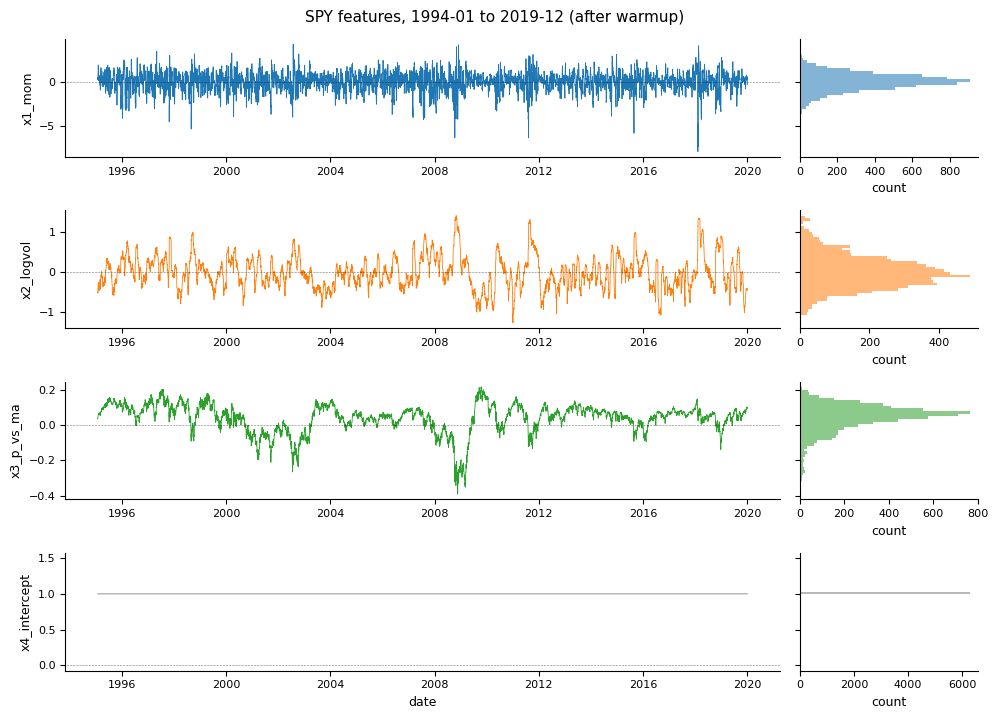

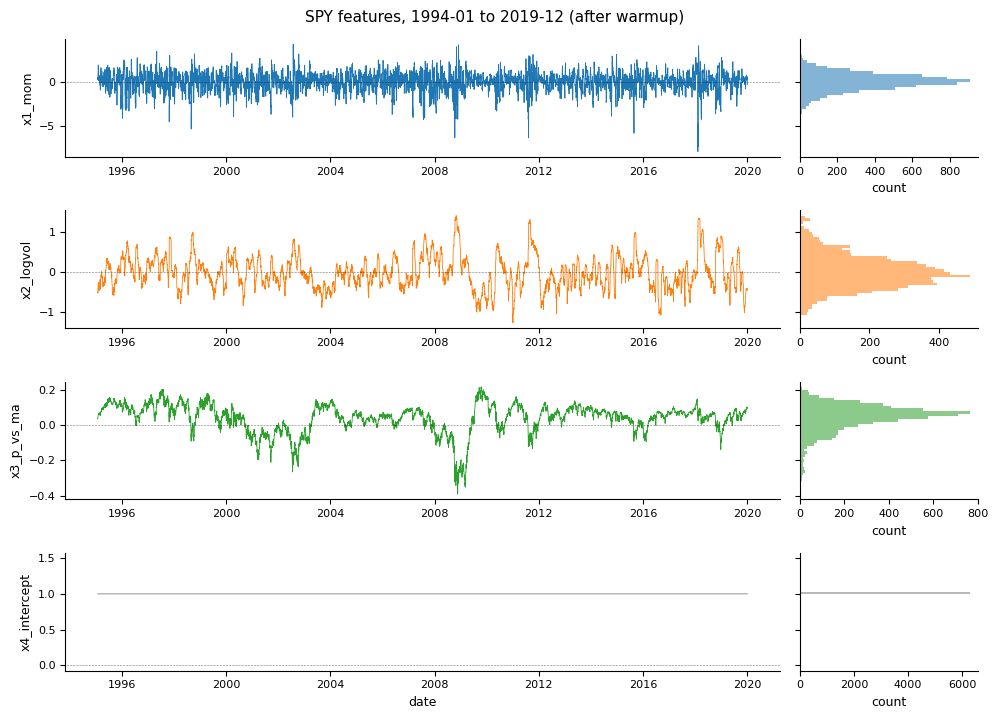

In [3]:
train = spy.loc[data.TRAIN_START:data.TRAIN_END]
feat_train = features.build_features(train).dropna()

fig, axes = plots.plot_feature_panel(feat_train)
fig.suptitle("SPY features, 1994-01 to 2019-12 (after warmup)", fontsize=11, y=1.02)
fig


## MC return constructor: closed-form sanity check

For a constant per-step reward `R_t = c`, the truncated MC return is
`y_t = c * (1 - gamma^(H+1)) / (1 - gamma)` for every fully-observed `t`.
This isolates the targets machinery from any environment / action choice.


In [4]:
H = targets.H_DEFAULT
gamma = targets.GAMMA_DEFAULT
c = 0.001

R_const = pd.Series(np.full(2_000, c), index=pd.date_range("1994-01-03", periods=2_000, freq="B"))
y_const = targets.mc_returns(R_const, gamma=gamma, H=H)

expected = c * (1 - gamma**(H + 1)) / (1 - gamma)
print(f"H={H}, gamma={gamma}")
print(f"len(R)        = {len(R_const)}")
print(f"len(y)        = {len(y_const)}    (expected {len(R_const) - H})")
print(f"y[0]          = {y_const.iloc[0]:.8f}")
print(f"closed form   = {expected:.8f}")
print(f"max abs error = {(y_const - expected).abs().max():.2e}")
print(f"truncation bias bound (worst case fraction) = {targets.truncation_bias_bound():.4f}")


H=60, gamma=0.95
len(R)        = 2000
len(y)        = 1940    (expected 1940)
y[0]          = 0.01912467
closed form   = 0.01912467
max abs error = 3.47e-18
truncation bias bound (worst case fraction) = 0.0438


## Right-edge truncation

`mc_returns` refuses to emit a target unless the full window
`R[t..t+H]` is observed. Below we corrupt the last day of `R` with
`NaN` (mimicking the real `step_reward`, where the final day has no
`r_{t+1}`) and confirm one extra row is dropped.


In [5]:
R_corrupt = R_const.copy()
R_corrupt.iloc[-1] = np.nan
y_corrupt = targets.mc_returns(R_corrupt, gamma=gamma, H=H)
print(f"len(y) with clean tail       = {len(y_const)}")
print(f"len(y) with one trailing NaN = {len(y_corrupt)}    (expected {len(y_const) - 1})")


len(y) with clean tail       = 1940
len(y) with one trailing NaN = 1939    (expected 1939)


## MC target distribution on real SPY returns

The Bayesian sampler regresses `beta_a` against `y_t`, so the distribution of
`y_t` is what shapes the posterior. Below we feed SPY's daily log returns
directly into `mc_returns` -- this is the target distribution an idealised
always-long, no-cost agent would see. The real reward depends on action
choices and turnover costs (notebook 02), but the rough scale and tail
behaviour of `y_t` are already determined by the underlying return process.


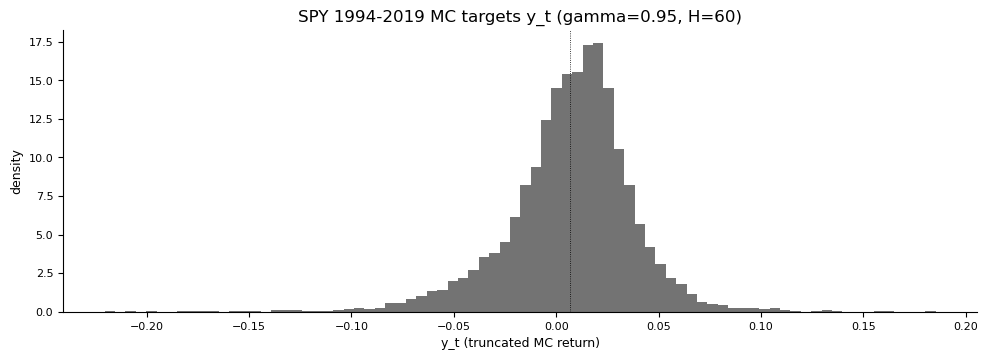

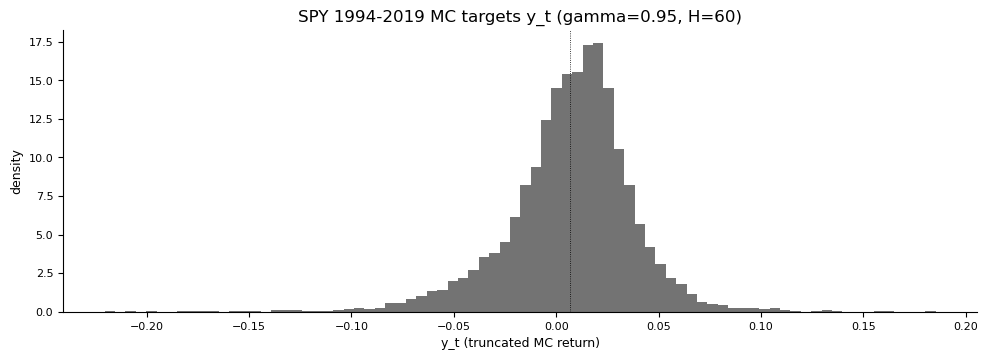

In [6]:
r_train = np.log(train["Close"]).diff()
y_real = targets.mc_returns(r_train, gamma=gamma, H=H)

fig, ax = plots.plot_mc_target_distribution(y_real)
ax.set_title(f"SPY 1994-2019 MC targets y_t (gamma={gamma}, H={H})")
ax.axvline(float(y_real.mean()), color="black", linestyle=":", linewidth=0.6)
fig


## Test-window regime summary

Closing visual: rolling realised volatility (annualised, 60-day window) and
running drawdown over the **test window** (2020-04 -> 2026). This is the
evaluation period for every modelling notebook downstream. The COVID crash
in 2020-Q1, the 2022 bear market, and the late-2024 ramp are all in scope.
Whatever an agent claims to do, it has to do it through these regimes.


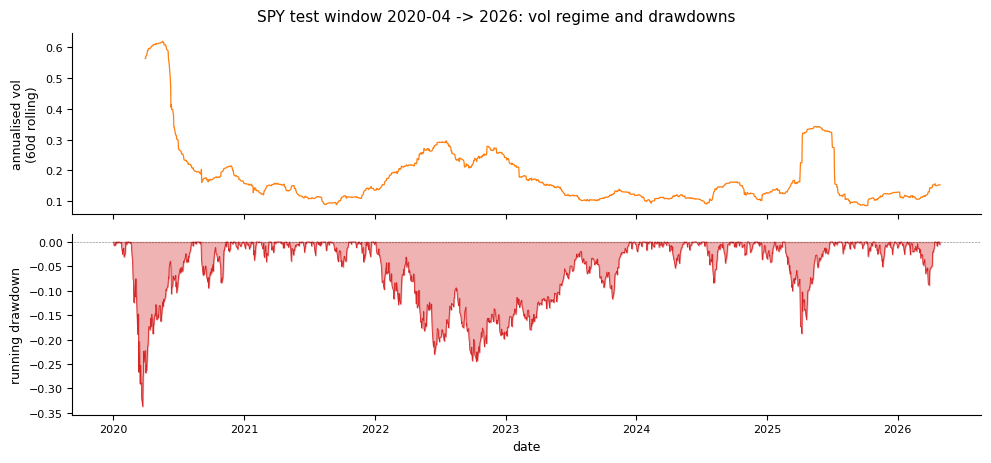

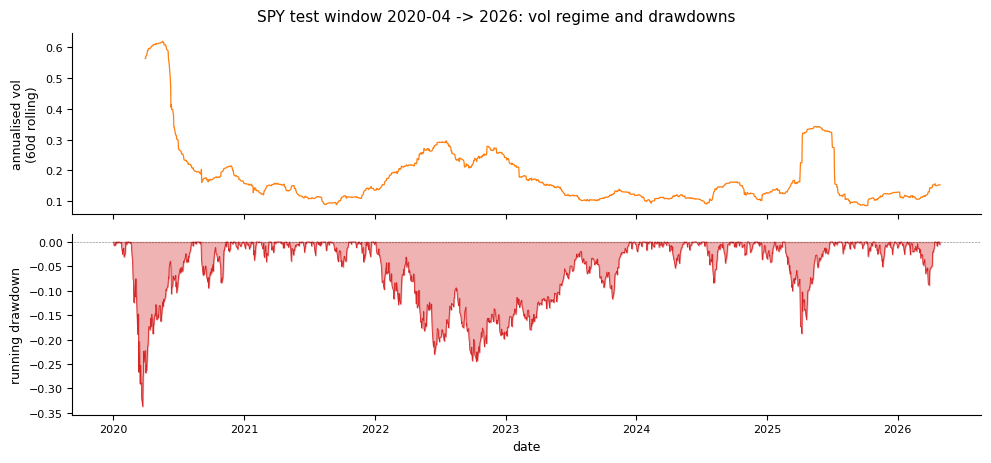

In [7]:
test = spy.loc[data.TEST_START:data.TEST_END]
fig, axes = plots.plot_regime_summary(test, rolling_window=60)
fig.suptitle("SPY test window 2020-04 -> 2026: vol regime and drawdowns", fontsize=11, y=1.02)
fig


## Sanity assertions


In [8]:
# Features matrix has the four expected columns in the documented order
assert tuple(feat.columns) == features.FEATURE_COLS

# After the warmup, no NaNs
assert feat.dropna().shape[0] >= len(spy) - features.feature_warmup() - 1

# Intercept is exactly 1
assert (feat["x4_intercept"] == 1.0).all()

# MC return constructor: closed-form match within float tolerance
assert (y_const - expected).abs().max() < 1e-12

# Truncation bias is below the proposal's "<5%" claim at H=60, gamma=0.95
assert targets.truncation_bias_bound() < 0.05

# MC targets on real returns: same length contract, no NaN
assert len(y_real) == len(r_train.dropna()) - H
assert y_real.notna().all()

print("OK")


OK
